# Phase 5 Persona Clustering (Final)

This notebook runs and inspects the finalized 6-feature Phase 5 clustering pipeline.

In [1]:
from pathlib import Path
import json
import pandas as pd

root = Path.cwd()
if (root / 'Simulation_4').exists():
    REPO_ROOT = root
else:
    REPO_ROOT = root.parent.parent

PHASE5_SCRIPT = REPO_ROOT / 'Simulation_4' / 'scripts' / 'phase 5' / 'phase5_persona_clustering.py'
OUT_DIR = REPO_ROOT / 'Simulation_4' / 'artifacts' / 'phase 5'
PHASE5_SCRIPT, OUT_DIR

(PosixPath('/Users/niyatisingh/Desktop/Sem-6/RL-AML Project/AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/Simulation_4/scripts/phase 5/phase5_persona_clustering.py'),
 PosixPath('/Users/niyatisingh/Desktop/Sem-6/RL-AML Project/AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/Simulation_4/artifacts/phase 5'))

In [2]:
import subprocess

cmd = ['python', str(PHASE5_SCRIPT)]
run = subprocess.run(cmd, cwd=REPO_ROOT, capture_output=True, text=True)
print(run.stdout)
if run.returncode != 0:
    print(run.stderr)
    raise RuntimeError(f'Phase 5 script failed with code {run.returncode}')

Loaded features from: /Users/niyatisingh/Desktop/Sem-6/RL-AML Project/AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/Simulation_4/artifacts/phase 1/extract5_behavioral_feature_table.csv

Null check (raw features):
relative_turn_count           0
total_values_provided         0
avg_values_per_action_turn    0
escalation_flag               0
resolution_flag               0
action_count                  0
forward_progress_rate         0
member_level_encoded          0

Scaled feature summary (mean, std):
                            scaled_mean  scaled_std
relative_turn_count            0.210335    0.077766
total_values_provided          0.123983    0.093062
avg_values_per_action_turn     0.323554    0.208882
escalation_flag                0.058753    0.235174
resolution_flag                0.863971    0.342836
action_count                   0.114476    0.060601
forward_progress_rate          0.237589    0.089757
member_level_encoded           0.50069

In [ ]:
stability = pd.read_csv(OUT_DIR / 'phase5_k_stability_table_final.csv')
profiles = pd.read_csv(OUT_DIR / 'phase5_cluster_profiles.csv')
validation = pd.read_csv(OUT_DIR / 'phase5_validation_checks_final.csv')
clustered_final = pd.read_csv(OUT_DIR / 'extract5_with_clusters_final.csv')

print('Stability table (final)')
display(stability)
print('Cluster profiles (final)')
display(profiles)
print('Validation checks (final)')
display(validation)
print('Cluster sample (final)')
display(clustered_final.head(20))

Stability table


,k,silhouette_score,inertia,inertia_drop,inertia_drop_pct
0,3,0.434777,1467.379983,NaN,NaN
1,4,0.461319,1130.874259,336.505724,0.229324
2,5,0.414938,941.548057,189.326202,0.167416
3,6,0.404973,759.412804,182.135253,0.193442


Cluster profiles


,cluster_id,size,frequency,relative_turn_count,total_values_provided,avg_values_per_action_turn,escalation_flag,resolution_flag,action_count,forward_progress_rate,...,turn_norm,progress_norm,action_norm,freq,rho_mean,sigma_mean,tau_mean,rho_std,sigma_std,tau_std
0,0,4409,0.439056,1.002993,3.843048,0.975023,0.0,1.0,3.702427,0.173635,...,0.428211,0.827880,1.000000,0.439056,0.625541,0.141309,0.900000,0.093657,0.093657,0.093657
1,1,4267,0.424915,0.995775,3.719709,0.983877,0.0,1.0,3.593860,0.170700,...,0.379228,0.620874,0.570346,0.424915,0.602030,0.190990,0.762511,0.094505,0.094505,0.094505
2,2,776,0.077275,0.939895,3.457474,0.964766,0.0,0.0,3.449742,0.176075,...,0.000000,1.000000,0.000000,0.077275,0.100000,0.100000,0.100000,0.115363,0.115363,0.115363
3,3,590,0.058753,1.087246,3.138983,0.850239,1.0,0.0,3.637288,0.161898,...,1.000000,0.000000,0.742213,0.058753,0.580000,0.900000,0.337508,0.116475,0.116475,0.116475


Validation checks


,check,expected_cluster,observed_cluster,holds
0,cooperative has highest resolution,1,0,False
1,cooperative has lowest escalation,1,0,False
2,escalation-prone has highest escalation,3,3,True
3,silent-dropout has lowest relative_turn_count,2,2,True
4,silent-dropout has lowest total_values_provided,2,3,False


Representatives


,cluster_id,label,convo_id,subflow,member_level,relative_turn_count,total_values_provided,avg_values_per_action_turn,escalation_flag,resolution_flag,action_count,forward_progress_rate
0,0,impatient,308,manage_change_phone,gold,1.002725,4.0,1.00,0.0,1.0,4.0,0.173913
1,0,impatient,2299,status_due_amount,gold,0.934737,4.0,1.00,0.0,1.0,4.0,0.166667
2,1,cooperative,2207,status_due_date,guest,1.031764,4.0,1.00,0.0,1.0,4.0,0.160000
3,1,cooperative,5683,status_due_date,guest,1.031764,4.0,1.00,0.0,1.0,4.0,0.160000
4,2,silent_dropout,6711,status_service_removed,bronze,1.067752,3.0,0.75,0.0,0.0,4.0,0.166667
5,2,silent_dropout,9634,status_due_date,bronze,0.784141,4.0,1.00,0.0,0.0,4.0,0.210526
6,3,escalation_prone,2630,out_of_stock_one_item,bronze,1.117302,4.0,1.00,1.0,0.0,4.0,0.166667
7,3,escalation_prone,3599,out_of_stock_general,bronze,1.186860,3.0,0.75,1.0,0.0,4.0,0.166667


## Cluster Visualizations

The cells below visualize the learned persona clusters from multiple angles.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

clustered = pd.read_csv(OUT_DIR / 'extract5_with_clusters_final.csv')

feature_cols = [
    'relative_turn_count',
    'total_values_provided',
    'avg_values_per_action_turn',
    'forward_progress_rate',
    'resolution_flag',
    'escalation_flag',
]

if len(feature_cols) < 2:
    raise ValueError(f'Need at least 2 numeric features for visualization, found: {feature_cols}')

clustered['cluster_id'] = clustered['cluster_id'].astype(int)
if 'persona_label' not in clustered.columns:
    clustered['cluster_label'] = clustered['cluster_id'].apply(lambda x: f'cluster_{int(x)}')
else:
    clustered['cluster_label'] = clustered['persona_label'].astype(str)

print('Using final feature columns:', feature_cols)
clustered[feature_cols + ['cluster_id', 'cluster_label']].head()

Using feature columns: ['member_level_encoded', 'relative_turn_count', 'escalation_flag', 'resolution_flag', 'action_count', 'forward_progress_rate', 'total_values_provided', 'avg_values_per_action_turn']


,member_level_encoded,relative_turn_count,escalation_flag,resolution_flag,action_count,forward_progress_rate,total_values_provided,avg_values_per_action_turn,cluster_id,cluster_label
0,1,1.318841,0,1,7,0.333333,0,0.000000,1,cluster_1
1,1,1.270903,0,1,9,0.450000,5,0.555556,1,cluster_1
2,3,0.671656,0,1,1,0.071429,0,0.000000,0,cluster_0
3,2,1.002725,0,1,4,0.173913,6,1.500000,0,cluster_0
4,1,0.873979,0,1,7,0.280000,6,0.857143,1,cluster_1


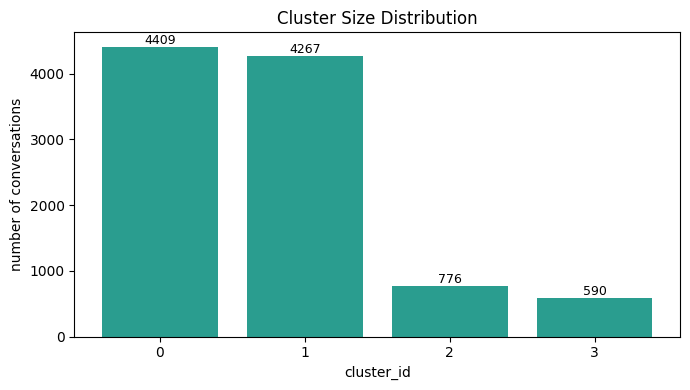

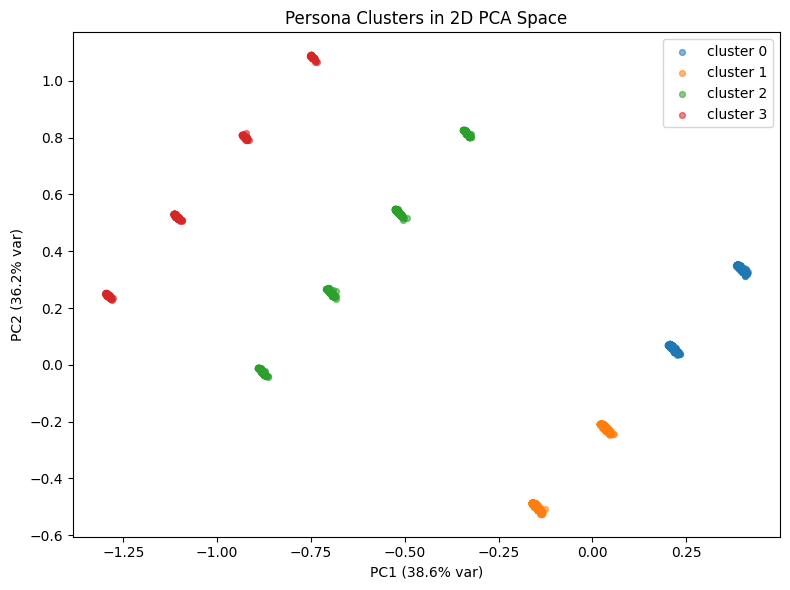

In [9]:
# 1) Cluster size distribution
cluster_counts = clustered['cluster_id'].value_counts().sort_index()
plt.figure(figsize=(7, 4))
bars = plt.bar(cluster_counts.index.astype(str), cluster_counts.values, color='#2A9D8F')
plt.title('Cluster Size Distribution')
plt.xlabel('cluster_id')
plt.ylabel('number of conversations')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h, f'{int(h)}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# 2) 2D PCA projection of clustered conversations
X = clustered[feature_cols].copy()
X_scaled = MinMaxScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    'pc1': X_2d[:, 0],
    'pc2': X_2d[:, 1],
    'cluster_id': clustered['cluster_id'].values,
    'cluster_label': clustered['cluster_label'].values,
})

plt.figure(figsize=(8, 6))
for cid, sub in plot_df.groupby('cluster_id'):
    plt.scatter(sub['pc1'], sub['pc2'], s=18, alpha=0.55, label=f'cluster {cid}')
plt.title('Persona Clusters in 2D PCA Space')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

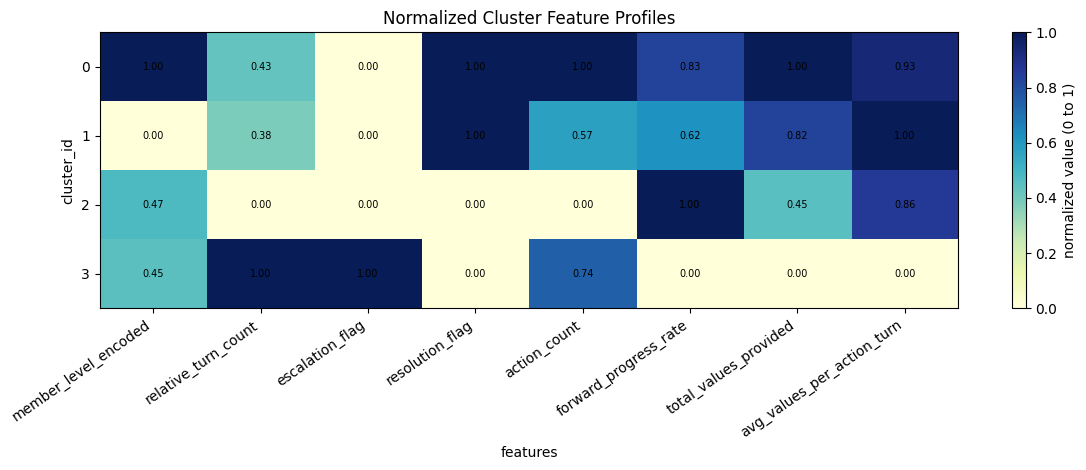

,member_level_encoded,relative_turn_count,escalation_flag,resolution_flag,action_count,forward_progress_rate,total_values_provided,avg_values_per_action_turn
cluster_id,,,,,,,,
0,2.516,1.003,0.0,1.0,3.702,0.174,3.843,0.975
1,0.480,0.996,0.0,1.0,3.594,0.171,3.720,0.984
2,1.443,0.940,0.0,0.0,3.450,0.176,3.457,0.965
3,1.392,1.087,1.0,0.0,3.637,0.162,3.139,0.850


In [10]:
# 3) Heatmap-style cluster profile comparison (normalized by feature min-max)
profile_means = clustered.groupby('cluster_id', as_index=True)[feature_cols].mean()
profile_norm = (profile_means - profile_means.min()) / (profile_means.max() - profile_means.min()).replace(0, 1)

fig, ax = plt.subplots(figsize=(12, 4.8))
im = ax.imshow(profile_norm.values, aspect='auto', cmap='YlGnBu')
ax.set_title('Normalized Cluster Feature Profiles')
ax.set_xlabel('features')
ax.set_ylabel('cluster_id')
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=35, ha='right')
ax.set_yticks(range(len(profile_norm.index)))
ax.set_yticklabels(profile_norm.index.astype(str))

for i in range(profile_norm.shape[0]):
    for j in range(profile_norm.shape[1]):
        val = profile_norm.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color='black')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('normalized value (0 to 1)')
plt.tight_layout()
plt.show()

display(profile_means.round(3))

In [ ]:
with open(OUT_DIR / 'persona_profiles.json', 'r', encoding='utf-8') as f:
    persona_payload = json.load(f)

print(json.dumps(persona_payload, indent=2))